In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(scales)
    library(reticulate)
    library(future)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [13]:
desisto2023 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/DeSisto_qc_filtered_and_normalized.rds')
desisto2023

An object of class Seurat 
16193 features across 6979 samples within 1 assay 
Active assay: RNA (16193 features, 0 variable features)
 1 layer present: data
 2 dimensional reductions calculated: pca, umap

In [25]:
smart <- readRDS('/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_smart_seq_datasets.rds')
smart

An object of class Seurat 
19283 features across 11767 samples within 3 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: prediction.score.coarse, prediction.score.gbmap.based
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [103]:
sussman2024_malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_malignant.RDS')

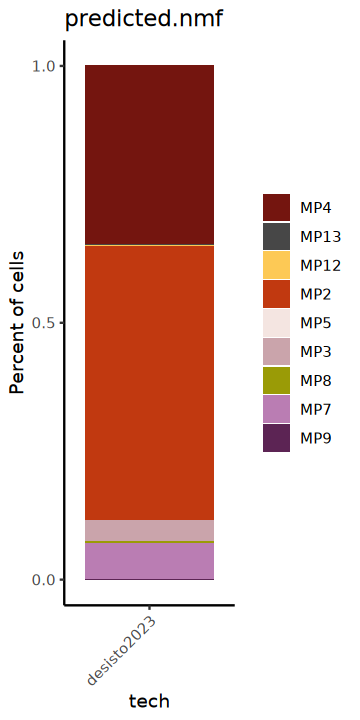

In [24]:
options(repr.plot.height = 6, repr.plot.width = 3)
desisto2023$tech <- 'desisto2023'


desisto2023$predicted.nmf <- factor(desisto2023$predicted.nmf,
                             levels=c('MP4','MP13', 'MP12','MP2','MP5','MP3','MP8','MP7','MP9'))
dittoBarPlot(desisto2023, var='predicted.nmf',group.by = 'tech', 
             color.panel = c( "#74150f", "#474747","#fdc955", 
                             "#c13910", "#f4e5e1",  "#caa4ab", 
                             "#9a9b06",
                             "#ba7db3","#5c2454" ),
             retain.factor.levels = TRUE)

In [109]:
ggsave('figures/barplot_desisto_malignant_predictions.pdf', height = 6, width = 3)

In [46]:
table(desisto2023$predicted.nmf)


 MP9  MP7  MP8  MP3  MP5  MP2 MP12 MP13  MP4 
   2  393   17  230    3 2962   12    8 1930 

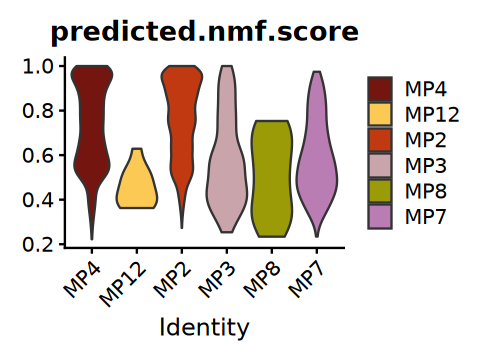

In [110]:
desisto2023$predicted.nmf <- factor(desisto2023$predicted.nmf,
                             levels=c('MP4','MP13', 'MP12','MP2','MP5','MP3','MP8','MP7','MP9'))
options(repr.plot.height = 3, repr.plot.width = 4)
VlnPlot(subset(desisto2023,
               predicted.nmf %in% c('MP13', 'MP5', 'MP9'),
               invert=TRUE), features = "predicted.nmf.score", 
        group.by = 'predicted.nmf', cols = c( "#74150f", "#fdc955", 
                             "#c13910",   "#caa4ab", 
                             "#9a9b06",
                             "#ba7db3" ), pt.size = 0) 

In [112]:
ggsave('figures/vlnplot_desisto_malignant_predictions.pdf', height = 3, width = 4)

Warning message:
“Cannot find cell-level meta data named  EGFR”
Warning message:
“Cannot find cell-level meta data named  PDGFRA”


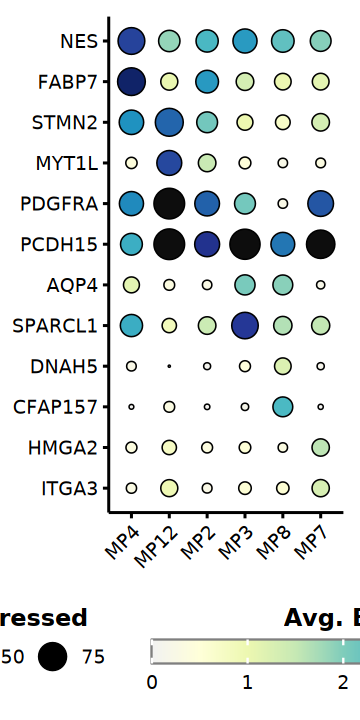

In [113]:
genes <- c('NES', 'FABP7',
                  'STMN2', 'MYT1L', 
                  'PDGFRA', 'PCDH15',  
                  'AQP4', 'SPARCL1',
                  'DNAH5', 'CFAP157',
                    'HMGA2','ITGA3'
  )

desisto2023$EGFR <- NULL
desisto2023$PDGFRA <- NULL

desisto2023$predicted.nmf <- factor(desisto2023$predicted.nmf,
                             levels=rev(c('MP4','MP13', 'MP12','MP2','MP5','MP3','MP8','MP7','MP9')))

options(repr.plot.height = 6, repr.plot.width = 3)
SCpubr::do_DotPlot(sample = subset(desisto2023,
                                   predicted.nmf %in% c('MP13', 'MP5', 'MP9'),
                                  invert=TRUE), 
                   group.by='predicted.nmf',
                   flip = TRUE,
                   max.cutoff = 5,
                        features = rev(genes), 
                        dot.scale = 8)

In [114]:
ggsave('figures/dotplot_desisto_malignant_predictions.pdf', height = 6, width = 3)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$la

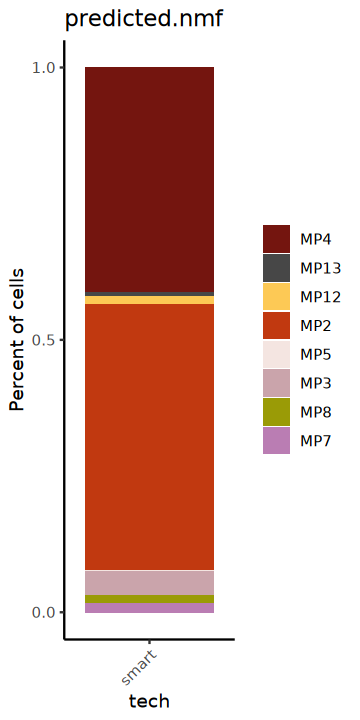

In [115]:
options(repr.plot.height = 6, repr.plot.width = 3)
smart$tech <- 'smart'


smart$predicted.nmf <- factor(smart$predicted.nmf,
                             levels=c('MP4','MP13', 'MP12','MP2','MP5','MP3','MP8','MP7'))
dittoBarPlot(smart, var='predicted.nmf',group.by = 'tech', 
             color.panel = c(   "#74150f", "#474747","#fdc955", 
                             "#c13910", "#f4e5e1",  "#caa4ab", 
                             "#9a9b06",
                             "#ba7db3"                         
             ),
             retain.factor.levels = TRUE)

In [116]:
ggsave('figures/barplot_smart_malignant_predictions.pdf', height = 6, width = 3)

In [60]:
table(smart$predicted.nmf)


MP12 MP13  MP2  MP3  MP4  MP5  MP7  MP8 
 100   39 3235  285 2735   11  101  105 

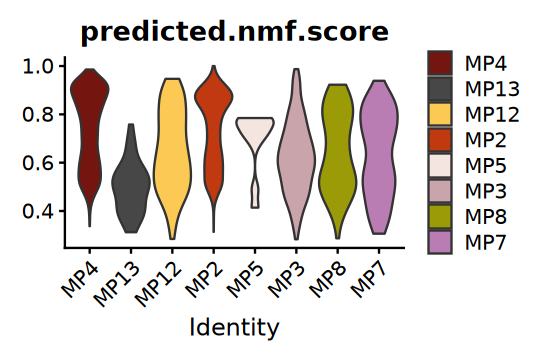

In [119]:
smart$predicted.nmf <- factor(smart$predicted.nmf,
                             levels=c('MP4','MP13', 'MP12','MP2','MP5','MP3','MP8','MP7'))
options(repr.plot.height = 3, repr.plot.width = 4.5)
VlnPlot(smart, features = "predicted.nmf.score", 
        group.by = 'predicted.nmf', cols = c(   "#74150f", "#474747","#fdc955", 
                             "#c13910", "#f4e5e1",  "#caa4ab", 
                             "#9a9b06",
                             "#ba7db3"                         
             ), pt.size = 0) 

In [120]:
ggsave('figures/vlnplot_smart_malignant_predictions.pdf', height = 3, width = 4.5)

Warning message:
“Cannot find cell-level meta data named  EGFR”
Warning message:
“Cannot find cell-level meta data named  PDGFRA”


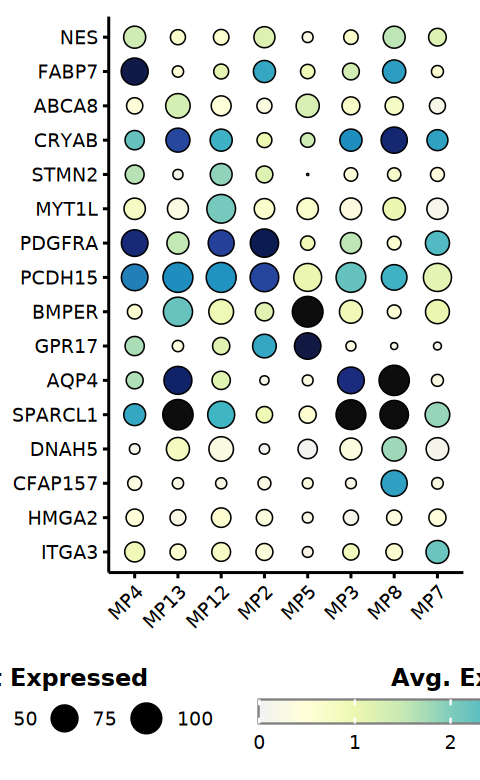

In [121]:
genes <- c('NES', 'FABP7',
                  'ABCA8', 'CRYAB', 
                  'STMN2', 'MYT1L', 
                  'PDGFRA', 'PCDH15', 
                  'BMPER', 'GPR17', 
                  'AQP4', 'SPARCL1', 
                  'DNAH5', 'CFAP157',
                    'HMGA2','ITGA3'
  )

smart$EGFR <- NULL
smart$PDGFRA <- NULL

smart$predicted.nmf <- factor(smart$predicted.nmf,
                             levels=rev(c('MP4','MP13', 'MP12','MP2','MP5','MP3','MP8','MP7')))

options(repr.plot.height = 6.5, repr.plot.width = 4)
SCpubr::do_DotPlot(sample = smart, group.by='predicted.nmf',
                   flip = TRUE,
                   max.cutoff = 5,
                        features = rev(genes), 
                        dot.scale = 8)

In [122]:
ggsave('figures/dotplot_smart_malignant_predictions.pdf', height = 6.5, width = 4)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$la

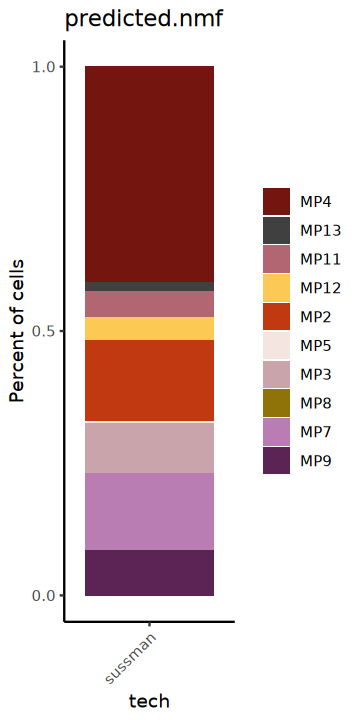

In [123]:
options(repr.plot.height = 6, repr.plot.width = 3)
sussman2024_malignant$tech <- 'sussman'


# smart$predicted.nmf <- factor(smart$predicted.nmf,
#                              levels=c('MP4','MP13', 'MP12','MP2','MP5','MP3','MP8','MP7'))
dittoBarPlot(sussman2024_malignant, var='predicted.nmf',group.by = 'tech', 
             color.panel = c("#74150f", "#404041", "#b26671", "#fdc955", "#c13910",'#f4e5e1', "#caa4ab", "#8f7308", 
    "#ba7db3", "#5c2454"       
             ),
             retain.factor.levels = TRUE)

In [124]:
ggsave('figures/barplot_sussman_malignant_predictions.pdf', height = 6, width = 3)

In [69]:
table(sussman2024_malignant$predicted.nmf)


   MP4   MP13   MP11   MP12    MP2    MP5    MP3    MP8    MP7    MP9 
104628   4497  12527  11115  39441    602  24438    174  37365  21568 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



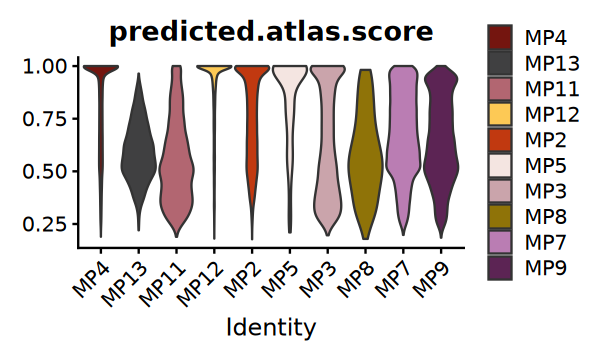

In [127]:
sussman2024_malignant$predicted.nmf <- factor(sussman2024_malignant$predicted.nmf,
                             levels=c('MP4','MP13', 'MP11','MP12','MP2','MP5','MP3','MP8','MP7','MP9'))
options(repr.plot.height = 3, repr.plot.width = 5)
VlnPlot(sussman2024_malignant, features = "predicted.atlas.score", 
        group.by = 'predicted.nmf', cols = c("#74150f", "#404041", "#b26671", "#fdc955", "#c13910",'#f4e5e1', "#caa4ab", "#8f7308", 
    "#ba7db3", "#5c2454"       
             ), pt.size = 0) 

In [128]:
ggsave('figures/vlnplot_sussman_malignant_predictions.pdf', height = 3, width = 5)

Warning message:
“Cannot find cell-level meta data named  EGFR”
Warning message:
“Cannot find cell-level meta data named  PDGFRA”


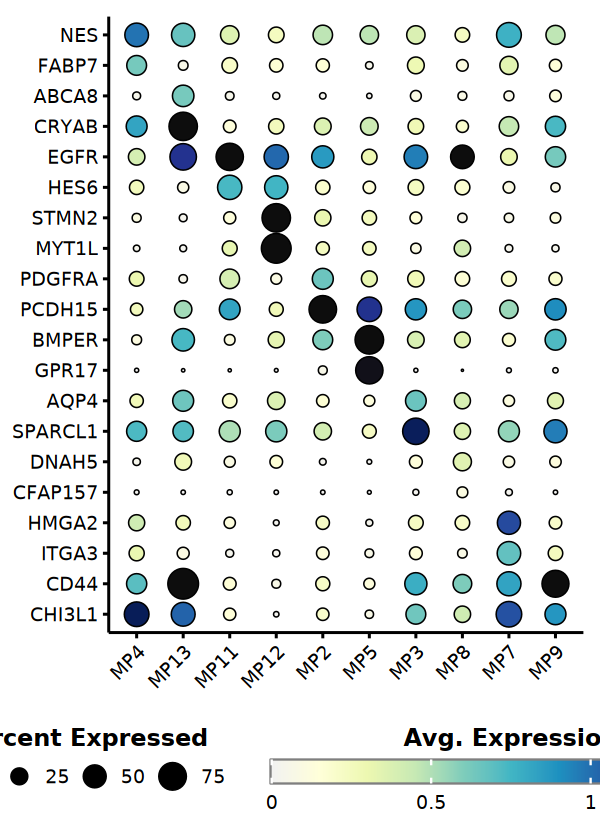

In [129]:
genes <- c('NES', 'FABP7',
                  'ABCA8', 'CRYAB', 
                  'EGFR', 'HES6', 
                  'STMN2', 'MYT1L', 
                  'PDGFRA', 'PCDH15', 
                  'BMPER', 'GPR17', 
                  'AQP4', 'SPARCL1', 
                  'DNAH5', 'CFAP157',
                    'HMGA2','ITGA3',
                    'CD44','CHI3L1'
  )

sussman2024_malignant$EGFR <- NULL
sussman2024_malignant$PDGFRA <- NULL

sussman2024_malignant$predicted.nmf <- factor(sussman2024_malignant$predicted.nmf,
                             levels=rev(c('MP4','MP13', 'MP11','MP12','MP2','MP5','MP3','MP8','MP7','MP9')))

options(repr.plot.height = 7, repr.plot.width = 5)
SCpubr::do_DotPlot(sample = sussman2024_malignant, group.by='predicted.nmf',
                   flip = TRUE,
                        features = rev(genes), 
                   max.cutoff = 1.5,
                        dot.scale = 8)

In [130]:
ggsave('figures/dotplot_sussman_malignant_predictions.pdf', height = 7, width = 5)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphi